In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from typing import Dict, Tuple, Optional
from dimod import ConstrainedQuadraticModel, Binary, Integer
import warnings
warnings.filterwarnings('ignore')
from dynex import DynexConfig, ComputeBackend, BQM, DynexSampler, QPUModel

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model=QPUModel.APOLLO_RC1, use_notebook_output=True)


In [2]:
from dynex import CQM


class TrafficOptimizationCQM:
    def __init__(self, numIntersections: int = 6, numRoads: int = 8):
        self.numIntersections = numIntersections
        self.numRoads = numRoads
        self.roadCapacities = {}
        self.travelTimes = {}
        self.trafficDemand = {}
        self.networkGraph = None
        self.cqmModel = None
        self.solution = None

        self._InitializeNetwork()
        self._GenerateTrafficData()

    def _InitializeNetwork(self) -> None:
        self.networkGraph = nx.Graph()

        for i in range(self.numIntersections):
            self.networkGraph.add_node(i, pos=self._GetNodePosition(i))

        roadConnections = [
            (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0),  # Outer ring
            (0, 3), (1, 4)
        ]

        for i, (start, end) in enumerate(roadConnections):
            if i < self.numRoads:
                self.networkGraph.add_edge(start, end, road_id=i)

    def _GetNodePosition(self, nodeId: int) -> Tuple[float, float]:
        angle = 2 * np.pi * nodeId / self.numIntersections
        radius = 2.0
        return (radius * np.cos(angle), radius * np.sin(angle))

    def _GenerateTrafficData(self) -> None:
        np.random.seed(42)

        for edge in self.networkGraph.edges():
            roadId = self.networkGraph[edge[0]][edge[1]]['road_id']
            self.roadCapacities[roadId] = np.random.randint(800, 1500)

        for edge in self.networkGraph.edges():
            roadId = self.networkGraph[edge[0]][edge[1]]['road_id']
            self.travelTimes[roadId] = np.random.uniform(2.0, 8.0)

        for i in range(self.numIntersections):
            for j in range(i + 1, self.numIntersections):
                self.trafficDemand[(i, j)] = np.random.randint(100, 400)

    def _BuildCQMModel(self) -> ConstrainedQuadraticModel:
        cqm = ConstrainedQuadraticModel()

        trafficFlowVars = {}  # int variables for traffic flow
        routeSelectionVars = {}  # Binary variables for route selection  
        signalTimingVars = {}  # int variables for signal timing

        for roadId in range(self.numRoads):
            varName = f'flow_road_{roadId}'
            capacity = self.roadCapacities.get(roadId, 1000)
            trafficFlowVars[roadId] = Integer(varName, lower_bound=0, upper_bound=capacity)

        for (origin, dest) in self.trafficDemand.keys():
            for pathId in range(3):
                varName = f'route_{origin}_{dest}_{pathId}'
                routeSelectionVars[(origin, dest, pathId)] = Binary(varName)

        for intersection in range(self.numIntersections):
            varName = f'signal_timing_{intersection}'
            signalTimingVars[intersection] = Integer(varName, lower_bound=0,
                                                     upper_bound=90)  # 0-90 range, represents 30-120 seconds

        self.trafficFlowVars = trafficFlowVars
        self.routeSelectionVars = routeSelectionVars
        self.signalTimingVars = signalTimingVars

        objective = 0

        # ttravel time component
        for roadId in range(self.numRoads):
            baseTime = self.travelTimes.get(roadId, 5.0)
            flowVar = trafficFlowVars[roadId]
            capacity = self.roadCapacities.get(roadId, 1000)

            # linear term: baseTime * flow
            objective += baseTime * flowVar

            congestionFactor = 0.0001 * baseTime / (capacity ** 2)
            objective += congestionFactor * flowVar * flowVar

        for intersection in range(self.numIntersections):
            signalVar = signalTimingVars[intersection]
            #penalty: 0.1 * ((signalVar + 30) - 60)^2 = 0.1 * (signalVar - 30)^2
            objective += 0.1 * (signalVar - 30) * (signalVar - 30)

        for (origin, dest, pathId) in routeSelectionVars.keys():
            routeVar = routeSelectionVars[(origin, dest, pathId)]
            penalty = 0.5 * pathId
            objective += penalty * routeVar

        cqm.set_objective(objective)
        for (origin, dest) in self.trafficDemand.keys():
            routeSum = 0
            for pathId in range(3):
                if (origin, dest, pathId) in routeSelectionVars:
                    routeSum += routeSelectionVars[(origin, dest, pathId)]

            if routeSum != 0:  # Only add constraint if we have routes
                cqm.add_constraint(routeSum == 1, label=f'route_selection_{origin}_{dest}')

        for roadId in range(self.numRoads):
            flowVar = trafficFlowVars[roadId]
            capacity = self.roadCapacities.get(roadId, 1000)
            cqm.add_constraint(flowVar <= capacity, label=f'capacity_road_{roadId}')

        for (origin, dest), demand in self.trafficDemand.items():
            representativeRoad = hash((origin, dest)) % self.numRoads
            flowVar = trafficFlowVars[representativeRoad]

            cqm.add_constraint(flowVar >= demand * 0.3,
                               label=f'demand_{origin}_{dest}_min')

        for i in range(self.numIntersections - 1):
            signal1 = signalTimingVars[i]
            signal2 = signalTimingVars[i + 1]
            cqm.add_constraint(signal1 - signal2 <= 30,
                               label=f'signal_coord_pos_{i}_{i + 1}')
            cqm.add_constraint(signal2 - signal1 <= 30,
                               label=f'signal_coord_neg_{i}_{i + 1}')

        self.cqmModel = cqm
        return cqm

    def _DynexCompute(self, timeLimit: int = 10) -> Optional[Dict]:
        if self.cqmModel is None:
            self._BuildCQMModel()
        model = CQM(self.cqmModel)
        sampler = DynexSampler(model, config=config)
        sampleset = sampler.sample(num_reads=1, annealing_time=100)
        self.solution = sampleset.first.sample
        print("Dynex Compute completed successfully!")
        print(f"   Best energy: {sampleset.first.energy:.2f}")
        return self.solution

    def _AnalyzeSolution(self) -> Dict:
        if self.solution is None:
            return {}

        analysis = {
            'total_travel_time': 0,
            'road_utilization': {},
            'signal_timings': {},
            'route_selections': {},
            'congestion_levels': {}
        }

        for roadId in range(self.numRoads):
            flowVar = f'flow_road_{roadId}'
            if flowVar in self.solution:
                flow = self.solution[flowVar]
                capacity = self.roadCapacities.get(roadId, 1000)
                utilization = flow / capacity if capacity > 0 else 0

                analysis['road_utilization'][roadId] = utilization
                analysis['congestion_levels'][roadId] = 'High' if utilization > 0.8 else \
                    'Medium' if utilization > 0.5 else 'Low'

                baseTime = self.travelTimes.get(roadId, 5.0)
                congestionMultiplier = 1 + 0.5 * (utilization ** 2)
                travelTime = baseTime * congestionMultiplier * flow
                analysis['total_travel_time'] += travelTime

        for intersection in range(self.numIntersections):
            signalVar = f'signal_timing_{intersection}'
            if signalVar in self.solution:
                actualTiming = self.solution[signalVar] + 30
                analysis['signal_timings'][intersection] = actualTiming

        for (origin, dest) in self.trafficDemand.keys():
            for pathId in range(3):
                routeKey = f'route_{origin}_{dest}_{pathId}'
                if routeKey in self.solution and self.solution[routeKey] == 1:
                    analysis['route_selections'][(origin, dest)] = pathId

        return analysis

    def VisualizeNetwork(self, figsize: Tuple[int, int] = (15, 10)) -> None:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Traffic Optimization Results - Quantum Annealing CQM',
                     fontsize=16, fontweight='bold')

        self._PlotNetworkTopology(ax1)
        self._PlotRoadUtilization(ax2)
        self._PlotSignalTimings(ax3)
        self._PlotPerformanceMetrics(ax4)
        plt.tight_layout()
        plt.show()

    def _PlotNetworkTopology(self, ax) -> None:
        ax.set_title('Traffic Network Topology & Flows', fontweight='bold')

        if self.networkGraph is None:
            return

        pos = nx.get_node_attributes(self.networkGraph, 'pos')

        nx.draw_networkx_nodes(self.networkGraph, pos, ax=ax,
                               node_color='lightblue', node_size=800,
                               edgecolors='navy', linewidths=2)

        if self.solution:
            edge_colors = []
            edge_widths = []

            for edge in self.networkGraph.edges():
                roadId = self.networkGraph[edge[0]][edge[1]]['road_id']
                flowKey = f'flow_road_{roadId}'

                if flowKey in self.solution:
                    flow = self.solution[flowKey]
                    capacity = self.roadCapacities.get(roadId, 1000)
                    utilization = flow / capacity

                    if utilization > 0.8:
                        edge_colors.append('red')
                    elif utilization > 0.5:
                        edge_colors.append('orange')
                    else:
                        edge_colors.append('green')

                    edge_widths.append(2 + 4 * utilization)
                else:
                    edge_colors.append('gray')
                    edge_widths.append(2)

            nx.draw_networkx_edges(self.networkGraph, pos, ax=ax,
                                   edge_color=edge_colors, width=edge_widths, alpha=0.7)
        else:
            nx.draw_networkx_edges(self.networkGraph, pos, ax=ax, edge_color='gray')

        nx.draw_networkx_labels(self.networkGraph, pos, ax=ax, font_size=12, font_weight='bold')

        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='green', lw=3, label='Low utilization (<50%)'),
            Line2D([0], [0], color='orange', lw=3, label='Medium utilization (50-80%)'),
            Line2D([0], [0], color='red', lw=3, label='High utilization (>80%)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
        ax.set_aspect('equal')
        ax.axis('off')

    def _PlotRoadUtilization(self, ax) -> None:
        ax.set_title('Road Utilization Analysis', fontweight='bold')
        if not self.solution:
            ax.text(0.5, 0.5, 'No solution available', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
            return

        roadIds = []
        utilizations = []
        colors = []

        for roadId in range(self.numRoads):
            flowKey = f'flow_road_{roadId}'
            if flowKey in self.solution:
                flow = self.solution[flowKey]
                capacity = self.roadCapacities.get(roadId, 1000)
                utilization = flow / capacity

                roadIds.append(f'Road {roadId}')
                utilizations.append(utilization * 100)

                if utilization > 0.8:
                    colors.append('red')
                elif utilization > 0.5:
                    colors.append('orange')
                else:
                    colors.append('green')

        bars = ax.bar(roadIds, utilizations, color=colors, alpha=0.7, edgecolor='black')
        ax.axhline(y=80, color='red', linestyle='--', alpha=0.8, label='High utilization threshold')
        ax.axhline(y=50, color='orange', linestyle='--', alpha=0.8, label='Medium utilization threshold')

        ax.set_ylabel('Utilization (%)')
        ax.set_xlabel('Roads')
        ax.set_ylim(0, 100)
        ax.legend()

        # Add value labels on bars
        for bar, util in zip(bars, utilizations):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height + 1,
                    f'{util:.1f}%', ha='center', va='bottom', fontweight='bold')

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    def _PlotSignalTimings(self, ax) -> None:
        ax.set_title('Optimized Traffic Signal Timings', fontweight='bold')

        if not self.solution:
            ax.text(0.5, 0.5, 'No solution available', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
            return

        intersections = []
        timings = []

        for intersection in range(self.numIntersections):
            timingKey = f'signal_timing_{intersection}'
            if timingKey in self.solution:
                intersections.append(f'Int. {intersection}')
                timings.append(self.solution[timingKey])

        bars = ax.bar(intersections, timings, color='skyblue', alpha=0.7, edgecolor='navy')
        ax.axhline(y=60, color='green', linestyle='--', alpha=0.8, label='Optimal timing (60s)')
        ax.set_ylabel('Signal Timing (seconds)')
        ax.set_xlabel('Intersections')
        ax.set_ylim(0, max(timings) * 1.1 if timings else 100)
        ax.legend()
        for bar, timing in zip(bars, timings):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height + 1,
                    f'{timing}s', ha='center', va='bottom', fontweight='bold')

    def _PlotPerformanceMetrics(self, ax) -> None:
        ax.set_title('Performance Metrics Summary', fontweight='bold')

        if not self.solution:
            ax.text(0.5, 0.5, 'No solution available', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
            return

        analysis = self._AnalyzeSolution()

        metrics = {
            'Avg. Road\nUtilization': np.mean(list(analysis['road_utilization'].values())) * 100,
            'High Congestion\nRoads': sum(1 for level in analysis['congestion_levels'].values()
                                          if level == 'High'),
            'Avg. Signal\nTiming': np.mean(list(analysis['signal_timings'].values())),
            'Total Travel\nTime (hrs)': analysis['total_travel_time'] / 60
        }

        y_pos = np.arange(len(metrics))
        values = list(metrics.values())
        labels = list(metrics.keys())

        colors = ['lightblue', 'orange', 'lightgreen', 'pink']
        bars = ax.barh(y_pos, values, color=colors, alpha=0.7, edgecolor='black')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels)
        ax.set_xlabel('Value')

        for i, (bar, value) in enumerate(zip(bars, values)):
            width = bar.get_width()
            ax.text(width + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{value:.1f}', ha='left', va='center', fontweight='bold')

        ax.set_xlim(0, max(values) * 1.2)

    def RunOptimization(self, timeLimit: int = 10) -> Dict:
        self._BuildCQMModel()
        solution = self._DynexCompute(timeLimit)
        if solution:
            analysis = self._AnalyzeSolution()
            print("\nOPTIMIZATION SUMMARY")
            print("-" * 30)
            print(f"Total Roads: {self.numRoads}")
            print(f"Total Intersections: {self.numIntersections}")
            if analysis:
                avgUtilization = np.mean(list(analysis['road_utilization'].values())) * 100
                highCongestionRoads = sum(1 for level in analysis['congestion_levels'].values()
                                          if level == 'High')
                print(f"Average Road Utilization: {avgUtilization:.1f}%")
                print(f"High Congestion Roads: {highCongestionRoads}")
                print(f"Total Travel Time: {analysis['total_travel_time'] / 60:.1f} hours")

            return analysis
        else:
            print("Optimization failed!")
            return {}

INFO: [DYNEX-APOLLO-RC1] Timing breakdown:
INFO: [DYNEX-APOLLO-RC1]   Job upload:        0.37s
INFO: [DYNEX-APOLLO-RC1]   Time to 1st shot:  24.72s
INFO: [DYNEX-APOLLO-RC1]   Compute (Apollo):  24.72s
INFO: [DYNEX-APOLLO-RC1]   Solution download: 0.05s
INFO: [DYNEX-APOLLO-RC1]   Total elapsed:     25.13s
INFO: [DYNEX-APOLLO-RC1] Finished read after 9.994999999999997 seconds
INFO: [DYNEX-APOLLO-RC1] Sampleset ready with energy   ... slack_v808f717bd2974a9eb00127678de6c857_6   energy num_oc.
0 ...                                         0 0.000016       1
['BINARY', 1 rows, 1 samples, 396 variables]


Dynex Compute completed successfully!
   Best energy: 18280.25

OPTIMIZATION SUMMARY
------------------------------
Total Roads: 8
Total Intersections: 6
Average Road Utilization: 42.1%
High Congestion Roads: 1
Total Travel Time: 355.8 hours


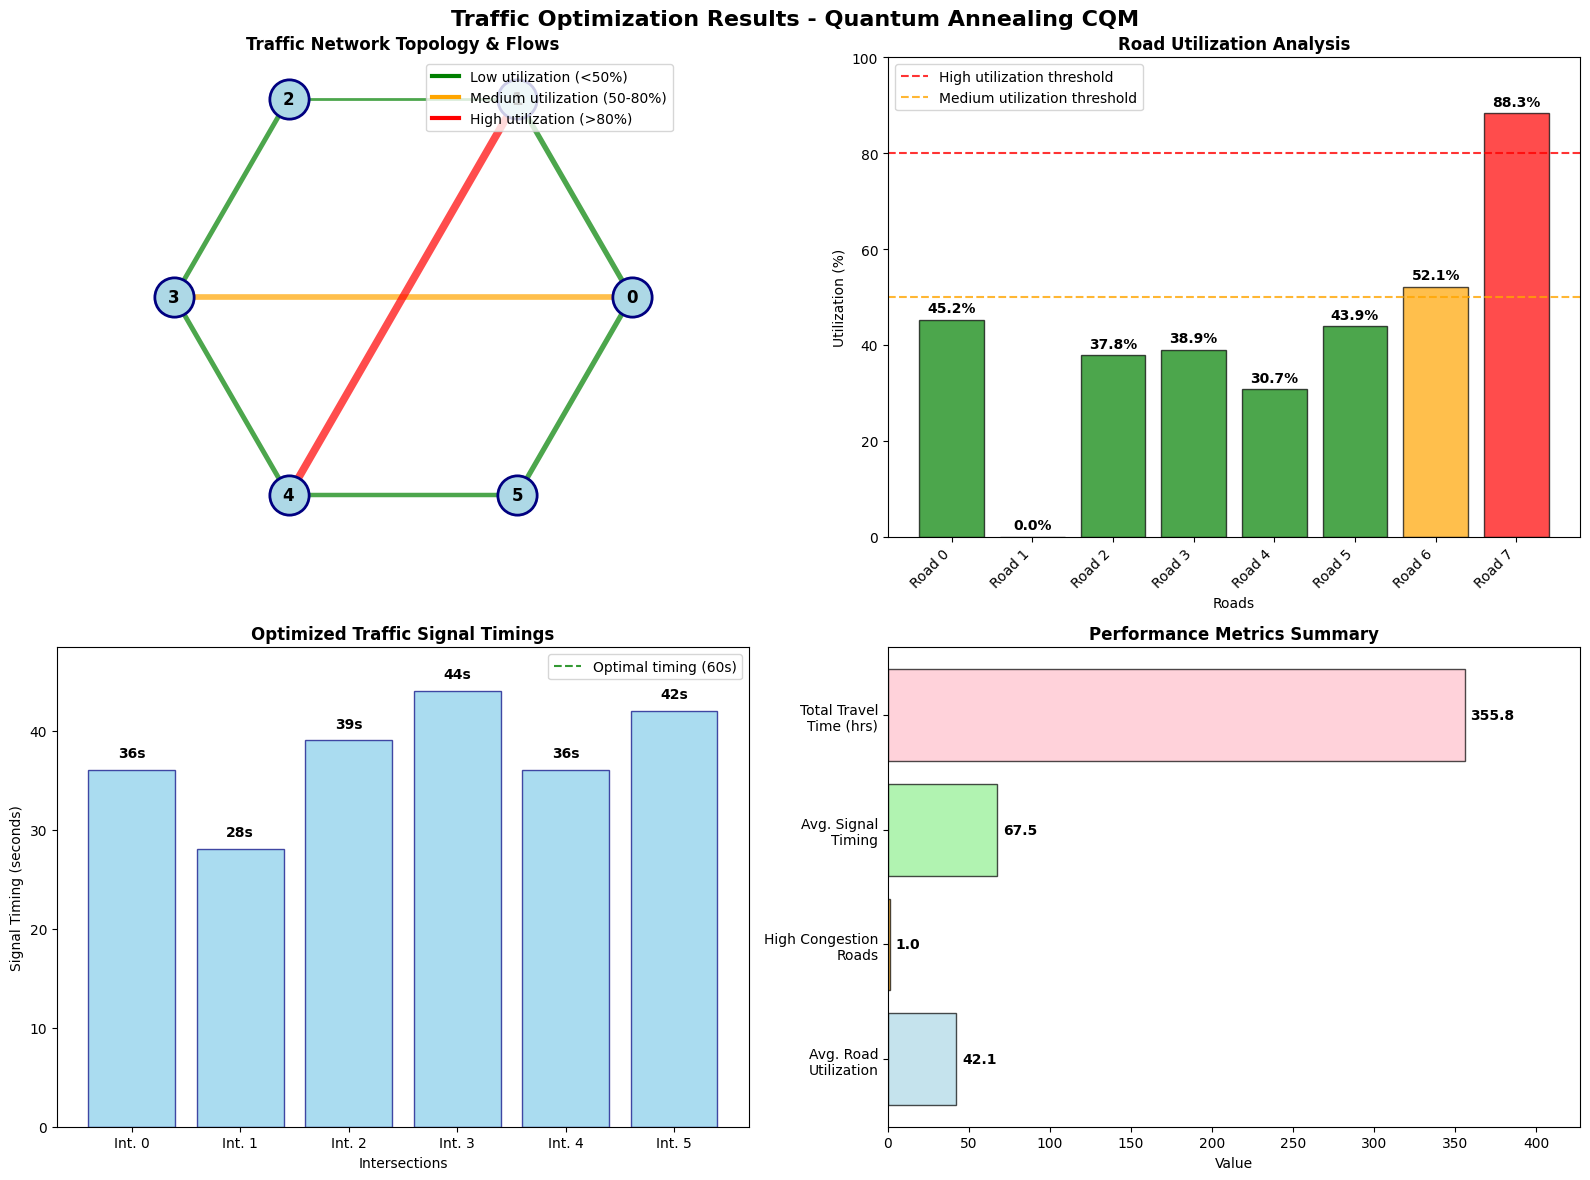

In [3]:
optimizer = TrafficOptimizationCQM(numIntersections=6, numRoads=8)
results = optimizer.RunOptimization(timeLimit=15)
optimizer.VisualizeNetwork(figsize=(16, 12))